# Error vs T

Log-log error plots comparing raw noisy data and Richardson extrapolated results.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 16})
plt.rcParams["text.usetex"] = True

N = 20
seed = 43
r_list = np.array([1, 2, 3, 7])
noise_list = r_list[::-1] ** 2  # [49, 9, 4, 1], matched to r = [1, 2, 3, 7]
T_list = np.array([0.2, 0.4, 0.8, 1.0, 2.0])

# Make paths work whether the notebook is launched from the repo root,
# tensor_network_numerics/, tensor_network_numerics/notebooks/active/, or nearby paths.
for candidate in [Path('.'), Path('..'), Path('../..'), Path('tensor_network_numerics')]:
    if (candidate / 'data' / 'N20' / 'sample_J0p5_h1_T_sweep').exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not locate tensor_network_numerics/data/N20/sample_J0p5_h1_T_sweep')

SAMPLE_DIR = ROOT / 'data' / 'N20' / 'sample_J0p5_h1_T_sweep'
EXACT_DIR = ROOT / 'data' / 'N20' / 'exact_results'
FIGURE_DIR = ROOT / 'figures'
PDF_PATH = FIGURE_DIR / f'error_vs_T_N_{N}_seed_{seed}.pdf'


def format_float_for_filename(value):
    text = f"{value:g}"
    return text.replace('-', 'm').replace('.', 'p')


def sample_path(r, T, noise):
    stem = f"r_{r}_T_{format_float_for_filename(T)}_noise_{int(noise)}_seed_{seed}"
    return SAMPLE_DIR / f"{stem}.txt"


def exact_path(T):
    stem = f"exact_N_{N}_J_0p5_h_1_T_{format_float_for_filename(T)}_r_10000"
    return EXACT_DIR / f"{stem}.json"


def read_sample_value(r, T, noise):
    path = sample_path(r, T, noise)
    if not path.exists():
        raise FileNotFoundError(path)
    text = path.read_text(encoding='utf-8').strip()
    value = text.split('=')[-1].strip() if '=' in text else text
    return float(value) / N


def read_exact_value(T):
    path = exact_path(T)
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open(encoding='utf-8') as f:
        data = json.load(f)
    return float(data['expectation_real']) / N


def richardson_coeffs(x_array, p=1):
    x_array = np.asarray(x_array, dtype=float)
    n = len(x_array)
    A = np.zeros((n, n))
    for i in range(n):
        A[i, :] = x_array ** (i * p)
    b = np.zeros(n)
    b[0] = 1.0
    return np.linalg.solve(A, b)


trotter_coeffs = richardson_coeffs(1 / r_list**2, p=1)
noise_coeffs = richardson_coeffs(noise_list, p=1)

print('r_list:', r_list)
print('noise_list:', noise_list)
print('T_list:', T_list)
print('Trotter coefficients:', trotter_coeffs)
print('Noise coefficients:', noise_coeffs)


r_list: [1 2 3 7]
noise_list: [49  9  4  1]
T_list: [0.2 0.4 0.8 1.  2. ]
Trotter coefficients: [-8.68055556e-04  9.48148148e-02 -4.55625000e-01  1.36167824e+00]
Noise coefficients: [-4.16666667e-04  1.22500000e-01 -6.53333333e-01  1.53125000e+00]


In [2]:
exact_by_T = {T: read_exact_value(T) for T in T_list}

raw_pairs = [
    (1, 49, r'$r=1, \lambda=49$'),
    (2, 9, r'$r=2, \lambda=9$'),
    (3, 4, r'$r=3, \lambda=4$'),
    (7, 1, r'$r=7, \lambda=1$'),
]

raw_errors = {}
for r, noise, label in raw_pairs:
    raw_errors[label] = np.array([
        abs(read_sample_value(r, T, noise) - exact_by_T[T])
        for T in T_list
    ])

extrapolated_values = {
    '1D extrapolation': [],
    '2D extrapolation': [],
    'Noiseless extrapolation': [],
}

for T in T_list:
    exact = exact_by_T[T]

    joint_values = np.array([
        read_sample_value(r, T, noise)
        for r, noise in zip(r_list, noise_list)
    ])
    noiseless_values = np.array([
        read_sample_value(r, T, 0)
        for r in r_list
    ])

    one_d = float(np.dot(trotter_coeffs, joint_values))
    noiseless = float(np.dot(trotter_coeffs, noiseless_values))

    trotter_by_noise = []
    for noise in noise_list:
        values_at_noise = np.array([
            read_sample_value(r, T, noise)
            for r in r_list
        ])
        trotter_by_noise.append(float(np.dot(trotter_coeffs, values_at_noise)))
    two_d = float(np.dot(noise_coeffs, np.array(trotter_by_noise)))

    extrapolated_values['1D extrapolation'].append(abs(one_d - exact))
    extrapolated_values['2D extrapolation'].append(abs(two_d - exact))
    extrapolated_values['Noiseless extrapolation'].append(abs(noiseless - exact))

extrapolated_errors = {
    label: np.array(values)
    for label, values in extrapolated_values.items()
}

print('Raw errors:')
for label, values in raw_errors.items():
    print(label, values)

print('\nExtrapolated errors:')
for label, values in extrapolated_errors.items():
    print(label, values)


Raw errors:
$r=1, \lambda=49$ [0.43516227 0.26406447 0.1610521  0.10564395 0.50844361]
$r=2, \lambda=9$ [0.18456227 0.14156447 0.0009979  0.12070395 0.04814639]
$r=3, \lambda=4$ [0.18490227 0.14360447 0.0231179  0.04122395 0.00603361]
$r=7, \lambda=1$ [2.72273882e-04 4.44689538e-05 3.21209689e-03 1.42839543e-02
 2.43763854e-02]

Extrapolated errors:
1D extrapolation [0.06675386 0.05217605 0.01467252 0.0120203  0.04094821]
2D extrapolation [0.23421301 0.19090121 0.06029916 0.02267768 0.06257753]
Noiseless extrapolation [2.42208836e-04 2.59849509e-04 6.94796099e-05 2.98423404e-03
 2.17412492e-02]


Saved PDF to ../figures/error_vs_T_N_20_seed_43.pdf


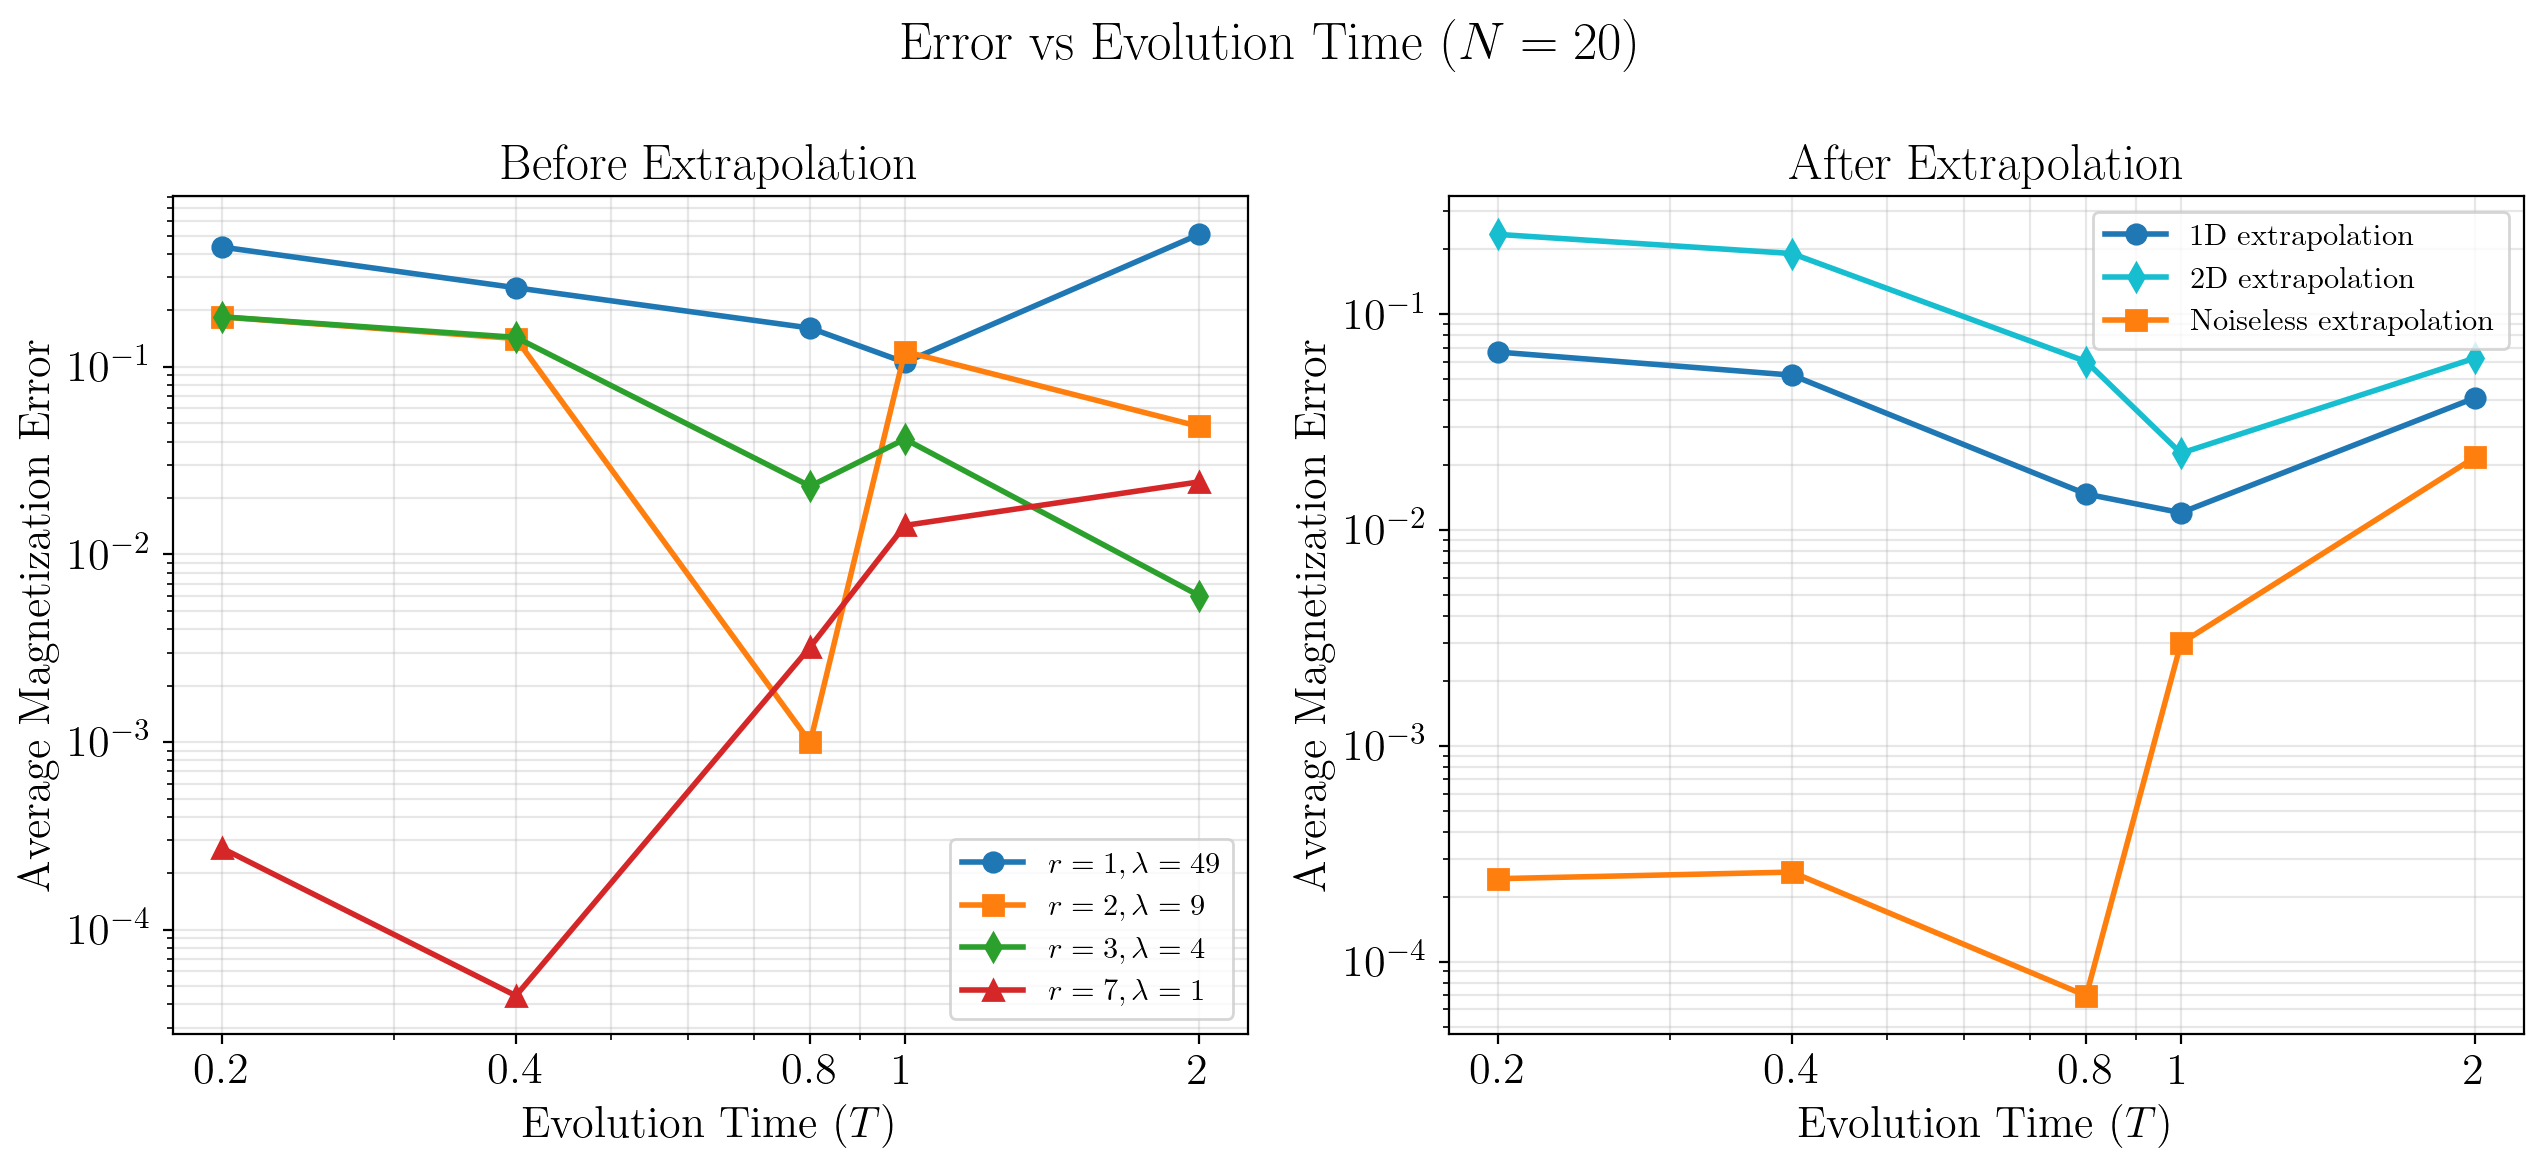

In [3]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    sharex=True,
    gridspec_kw={"width_ratios": [1, 1]},
)

raw_styles = ['o-', 's-', 'd-', '^-']
for (label, values), style in zip(raw_errors.items(), raw_styles):
    axs[0].plot(T_list, values, style, linewidth=2, markersize=7, label=label)
axs[0].set_title('Before Extrapolation', fontsize=18)
axs[0].set_xlabel(r'Evolution Time ($T$)')
axs[0].set_ylabel(r'Average Magnetization Error')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xticks(T_list)
axs[0].set_xticklabels([f'{T:g}' for T in T_list])
axs[0].grid(alpha=0.3, which='both')
axs[0].legend(loc='best', fontsize=11)

extrap_styles = {
    '1D extrapolation': ('o-', 'C0'),
    '2D extrapolation': ('d-', 'C9'),
    'Noiseless extrapolation': ('s-', 'C1'),
}
for label, values in extrapolated_errors.items():
    style, color = extrap_styles[label]
    axs[1].plot(T_list, values, style, color=color, linewidth=2, markersize=7, label=label)
axs[1].set_title('After Extrapolation', fontsize=18)
axs[1].set_xlabel(r'Evolution Time ($T$)')
axs[1].set_ylabel(r'Average Magnetization Error')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xticks(T_list)
axs[1].set_xticklabels([f'{T:g}' for T in T_list])
axs[1].grid(alpha=0.3, which='both')
axs[1].legend(loc='best', fontsize=11)

fig.suptitle(f'Error vs Evolution Time ($N={N}$)', y=0.98)
fig.tight_layout()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PDF_PATH, bbox_inches='tight')
print(f'Saved PDF to {PDF_PATH}')
plt.show()
